# Cost-Sensitive Loan Approval Modeling

## Executive overview

FinTech Innovations needs a consistent screening aid, not an unreviewed replacement for loan officers. The final interpretable logistic pipeline achieved **0.995 ROC-AUC** and **0.984 PR-AUC** on 4,000 untouched test applications. A **0.845** approval threshold, selected only from out-of-fold training predictions, reduced estimated test cost from **$7.648 million** for always denying to **$2.404 million** (**68.6% lower**) while recalling **80.3%** of historically approved applicants. The result exceeds all three stated success criteria, but the historical approval target is a policy proxy rather than observed repayment; the model should begin as governed decision support while outcomes, data lineage, calibration, and fairness are validated prospectively.

## 1. Business Understanding

### Decision context and stakeholders

The current manual review process can be slow and inconsistent because loan officers may weigh the same evidence differently. A model can standardize an initial risk screen, but should return a probability and reason codes so that borderline or exceptional cases remain reviewable.

- **Applicants** need timely, consistent decisions, explanations, an appeal path, and protection from discriminatory proxies.
- **Loan officers** need calibrated risk evidence and reason codes rather than a black-box verdict.
- **Risk and finance leaders** need lower expected losses without eliminating profitable lending.
- **Compliance/model-risk teams** need traceability, fairness monitoring, data lineage, and override governance.

This notebook chooses **classification** because the operational decision and available target are binary. A regression model for `RiskScore` would reproduce a derived score rather than validate whether an application should be approved. `RiskScore` is therefore excluded as target-adjacent leakage.

### Errors and financial objective

Here, class `1` means historically approved/treated as creditworthy and class `0` means denied/not creditworthy. Under that proxy:

- A **false positive** approves an applicant labeled bad: estimated loss **$50,000**.
- A **false negative** denies an applicant labeled good: estimated opportunity cost **$8,000**.

The custom portfolio cost is

$$C = 50{,}000\,FP + 8{,}000\,FN.$$

The false-positive error is 6.25 times more expensive. If probabilities are calibrated and those costs are the only consideration, approve when

$$P(\mathrm{good}\mid x) > \frac{50{,}000}{50{,}000 + 8{,}000} \approx 0.862.$$

That theoretical threshold is a reference point; the selected threshold will be estimated from out-of-fold training predictions.

### Success criteria

Primary metrics are **expected business cost** (directly aligned with the decision) and **ROC-AUC** (ranking quality independent of a threshold). **PR-AUC**, positive-class recall, precision, and F1 are secondary diagnostics because approvals are the minority class. Targets are: (1) reduce cost at least 25% relative to always denying, (2) ROC-AUC at least 0.85, and (3) positive-class recall at least 0.70 so the cost objective does not hide excessive exclusion. No single aggregate metric is sufficient for deployment.

In [1]:
# Imports and reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## 2. Data Understanding

The provided `financial_loan_data.csv` contains deliberately messy application records.

In [2]:
data = pd.read_csv("financial_loan_data.csv")
print(f"Rows: {data.shape[0]:,} | Columns: {data.shape[1]}")
display(data.head())

Rows: 20,000 | Columns: 35


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,DebtToIncomeRatio,BankruptcyHistory,LoanPurpose,PreviousLoanDefaults,PaymentHistory,LengthOfCreditHistory,SavingsAccountBalance,CheckingAccountBalance,TotalAssets,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,Own,183,0.354418,1,2,0.358336,No,Home,0,29,9,7632.0,1202,146111,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,Mortgage,496,0.087827,5,3,0.330274,No,Debt Consolidation,0,21,9,4627.0,3460,53204,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,Rent,902,0.137414,2,0,0.244729,No,Education,0,20,22,886.0,895,25176,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,Mortgage,755,0.267587,2,1,0.436244,No,Home,0,27,10,1675.0,1217,104822,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,Mortgage,274,0.320535,0,0,0.078884,No,Debt Consolidation,0,26,27,1555.0,4981,244305,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
# Basic quality audit
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_n": data.isna().sum(),
    "missing_pct": data.isna().mean().mul(100).round(2),
    "unique_n": data.nunique(dropna=False),
})
display(quality)
print(f"Exact duplicate rows: {data.duplicated().sum():,}")
print("\nTarget counts and proportions:")
display(pd.concat([
    data["LoanApproved"].value_counts().rename("count"),
    data["LoanApproved"].value_counts(normalize=True).rename("proportion")
], axis=1))

,dtype,missing_n,missing_pct,unique_n
Age,int64,0,0.00,63
AnnualIncome,object,0,0.00,17516
CreditScore,int64,0,0.00,322
EmploymentStatus,object,0,0.00,3
EducationLevel,object,901,4.50,6
Experience,int64,0,0.00,62
LoanAmount,int64,0,0.00,15578
LoanDuration,int64,0,0.00,10
MaritalStatus,object,1331,6.65,5
NumberOfDependents,int64,0,0.00,6


Exact duplicate rows: 0

Target counts and proportions:


,count,proportion
LoanApproved,,
0,15220,0.761
1,4780,0.239


### Feature roles and data-quality risks

- **Target:** `LoanApproved` (binary, imbalanced at roughly 24% approved).
- **Numeric/continuous or count:** income, score, balances, debt, assets, ratios, history lengths, payment values, and applicant/loan counts.
- **Ordinal:** `EducationLevel` (High School < Associate < Bachelor < Master < Doctorate).
- **Nominal:** employment, marital status, home ownership, bankruptcy history, and loan purpose.
- **Malformed numeric:** `AnnualIncome` is currency-formatted text and must be parsed inside the pipeline.
- **Missing:** education, marital status, and savings balance require training-fold imputation. Missingness may be informative, so monitoring it is more defensible than assuming it is random.
- **Outliers:** financial variables are right-skewed; they may be valid high-value customers rather than errors. Median imputation and scaling limit sensitivity without deleting applicants.
- **Leakage:** `RiskScore` is a derived outcome explicitly offered as an alternative target, so it cannot be a predictor of approval. Pricing/payment fields may only be usable if they are known before the decision; production data-lineage review is required.
- **Potential features:** loan-to-income, liquid balance, and asset-to-liability coverage expose affordability in interpretable terms.

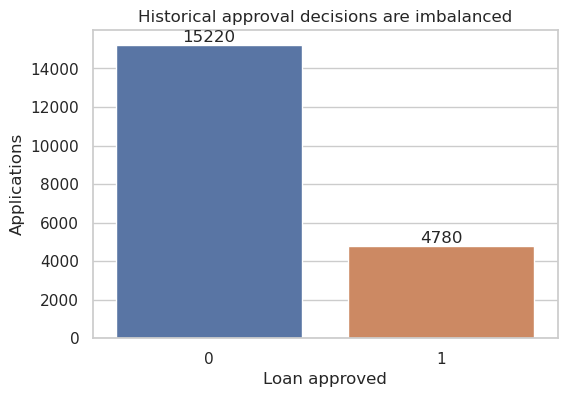

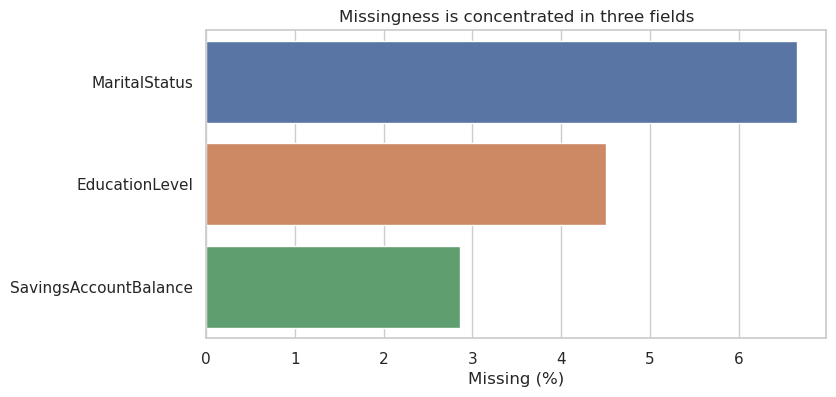

In [4]:
# EDA-only clean copy; production cleaning is repeated inside the model pipeline.
eda = data.copy()
eda["AnnualIncome"] = pd.to_numeric(
    eda["AnnualIncome"].str.replace(r"[$,]", "", regex=True), errors="coerce"
)

# Visualization 1: target imbalance
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda, x="LoanApproved", hue="LoanApproved", legend=False, ax=ax)
ax.set(title="Historical approval decisions are imbalanced", xlabel="Loan approved", ylabel="Applications")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()

# Visualization 2: missing-value profile
missing = eda.isna().mean().mul(100).sort_values(ascending=False)
missing = missing[missing.gt(0)]
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing.values, y=missing.index, hue=missing.index, legend=False, ax=ax)
ax.set(title="Missingness is concentrated in three fields", xlabel="Missing (%)", ylabel="")
plt.show()

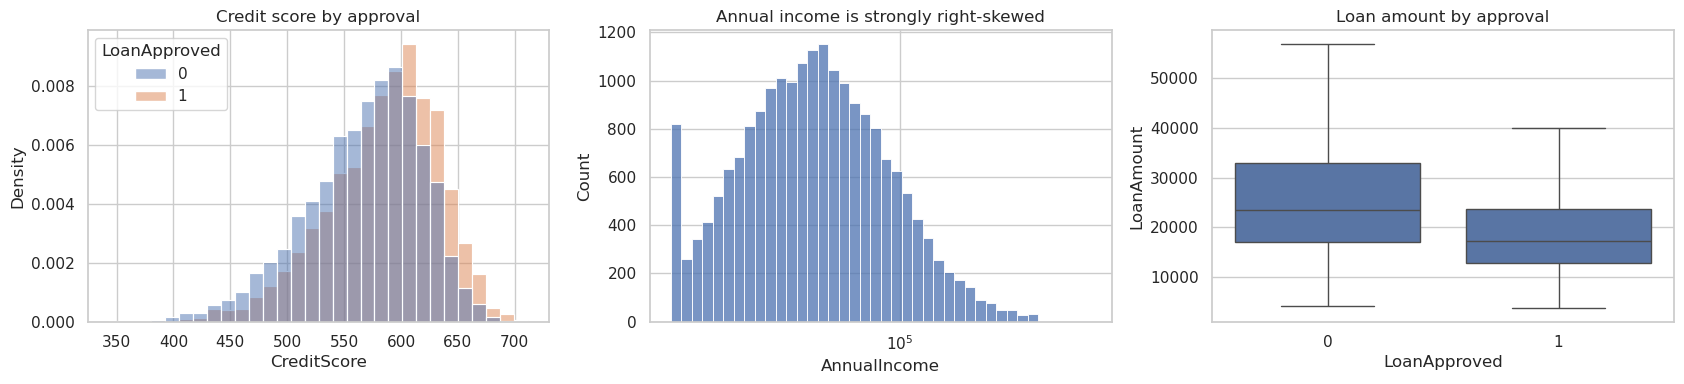

,mean,count
CreditScoreBand,,
Poor,0.148599,1891
Fair,0.201925,8310
Good,0.284337,9647
Very good,0.513158,152
Exceptional,NaN,0


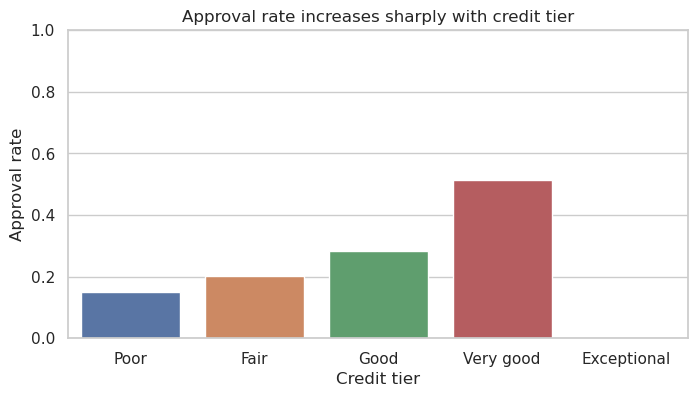

In [5]:
# Visualizations 3-5: numeric distributions, skew, and target separation
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
sns.histplot(data=eda, x="CreditScore", hue="LoanApproved", bins=30, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Credit score by approval")
sns.histplot(data=eda, x="AnnualIncome", bins=40, log_scale=True, ax=axes[1])
axes[1].set_title("Annual income is strongly right-skewed")
sns.boxplot(data=eda, x="LoanApproved", y="LoanAmount", showfliers=False, ax=axes[2])
axes[2].set_title("Loan amount by approval")
plt.tight_layout()
plt.show()

# Visualization 6: approval rate across ordered credit-score bins
eda["CreditScoreBand"] = pd.cut(
    eda["CreditScore"], bins=[299, 499, 579, 669, 739, 850],
    labels=["Poor", "Fair", "Good", "Very good", "Exceptional"]
)
credit_rates = eda.groupby("CreditScoreBand", observed=False)["LoanApproved"].agg(["mean", "count"])
display(credit_rates)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=credit_rates.reset_index(), x="CreditScoreBand", y="mean", hue="CreditScoreBand", legend=False, ax=ax)
ax.set(title="Approval rate increases sharply with credit tier", xlabel="Credit tier", ylabel="Approval rate", ylim=(0, 1))
plt.show()

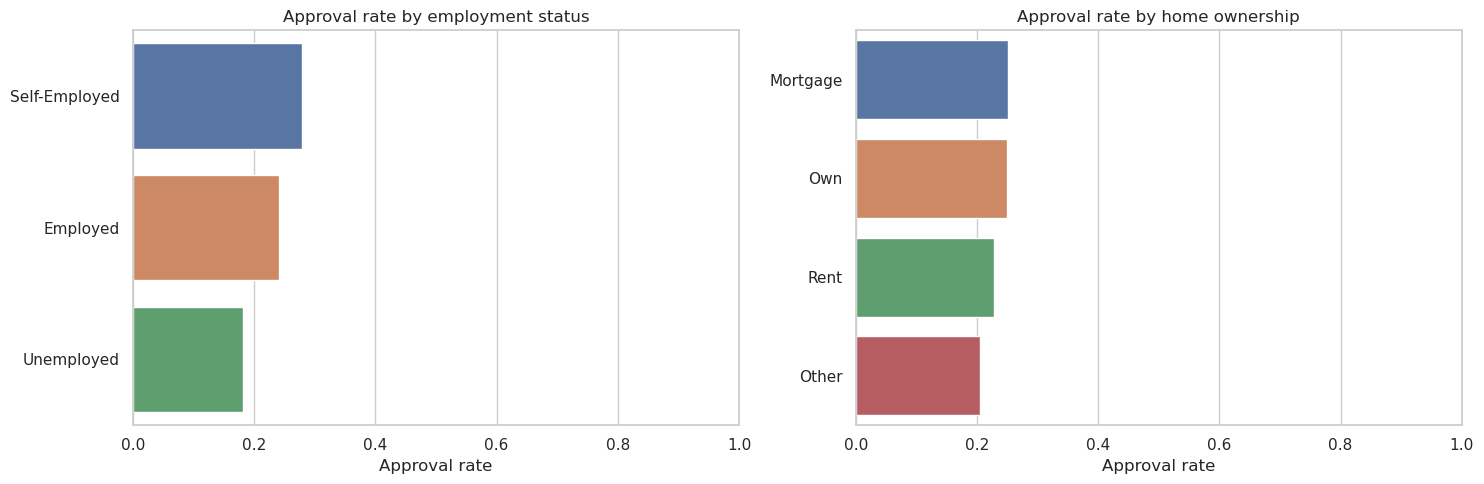

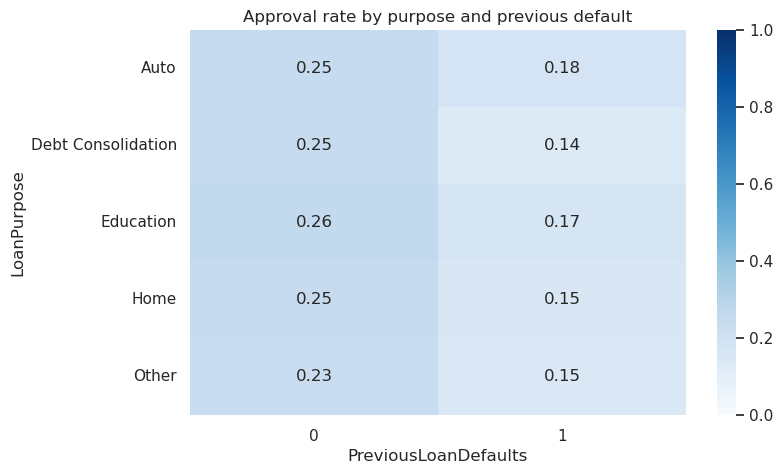

In [6]:
# Visualizations 7-8: nominal-feature approval patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
employment_rates = eda.groupby("EmploymentStatus")["LoanApproved"].mean().sort_values(ascending=False)
home_rates = eda.groupby("HomeOwnershipStatus")["LoanApproved"].mean().sort_values(ascending=False)
sns.barplot(x=employment_rates.values, y=employment_rates.index, hue=employment_rates.index, legend=False, ax=axes[0])
axes[0].set(title="Approval rate by employment status", xlabel="Approval rate", ylabel="", xlim=(0, 1))
sns.barplot(x=home_rates.values, y=home_rates.index, hue=home_rates.index, legend=False, ax=axes[1])
axes[1].set(title="Approval rate by home ownership", xlabel="Approval rate", ylabel="", xlim=(0, 1))
plt.tight_layout()
plt.show()

# Visualization 9: purpose and historical-default interaction
purpose_default = eda.pivot_table(
    index="LoanPurpose", columns="PreviousLoanDefaults", values="LoanApproved", aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(purpose_default, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Approval rate by purpose and previous default")
plt.show()

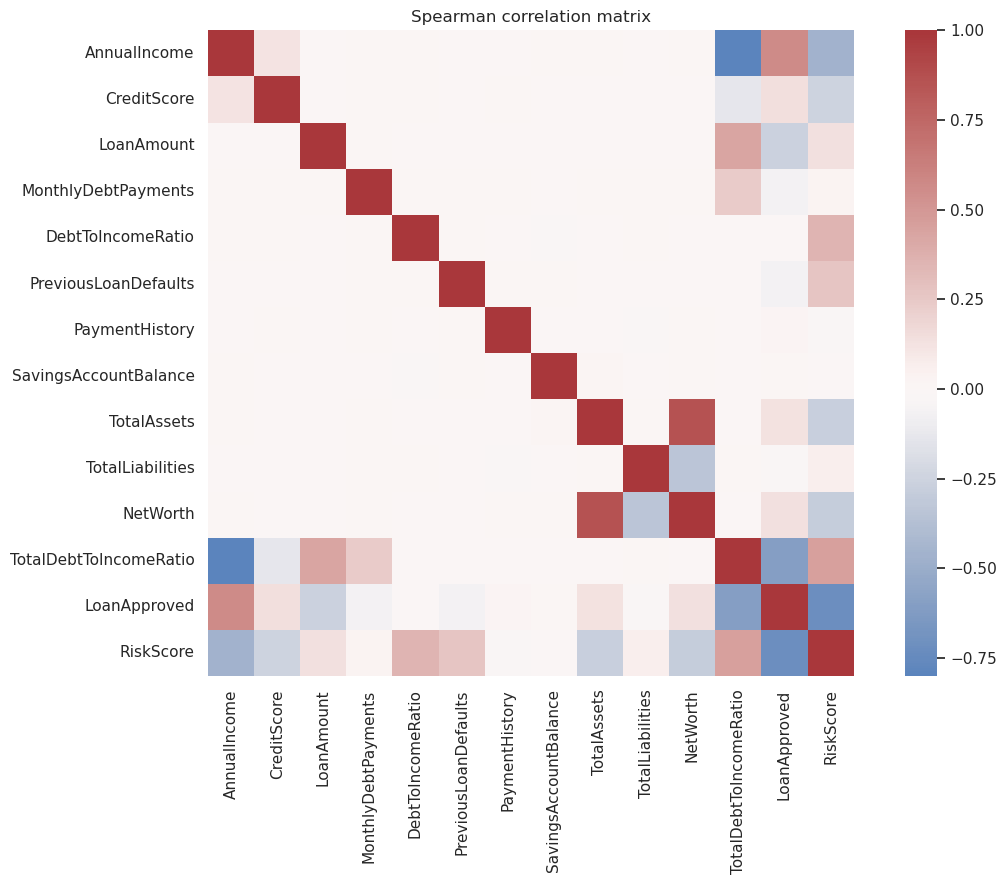

In [7]:
# Visualization 10: correlations among decision-relevant numeric features
corr_features = [
    "AnnualIncome", "CreditScore", "LoanAmount", "MonthlyDebtPayments",
    "DebtToIncomeRatio", "PreviousLoanDefaults", "PaymentHistory",
    "SavingsAccountBalance", "TotalAssets", "TotalLiabilities",
    "NetWorth", "TotalDebtToIncomeRatio", "LoanApproved", "RiskScore"
]
corr = eda[corr_features].corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Spearman correlation matrix")
plt.tight_layout()
plt.show()

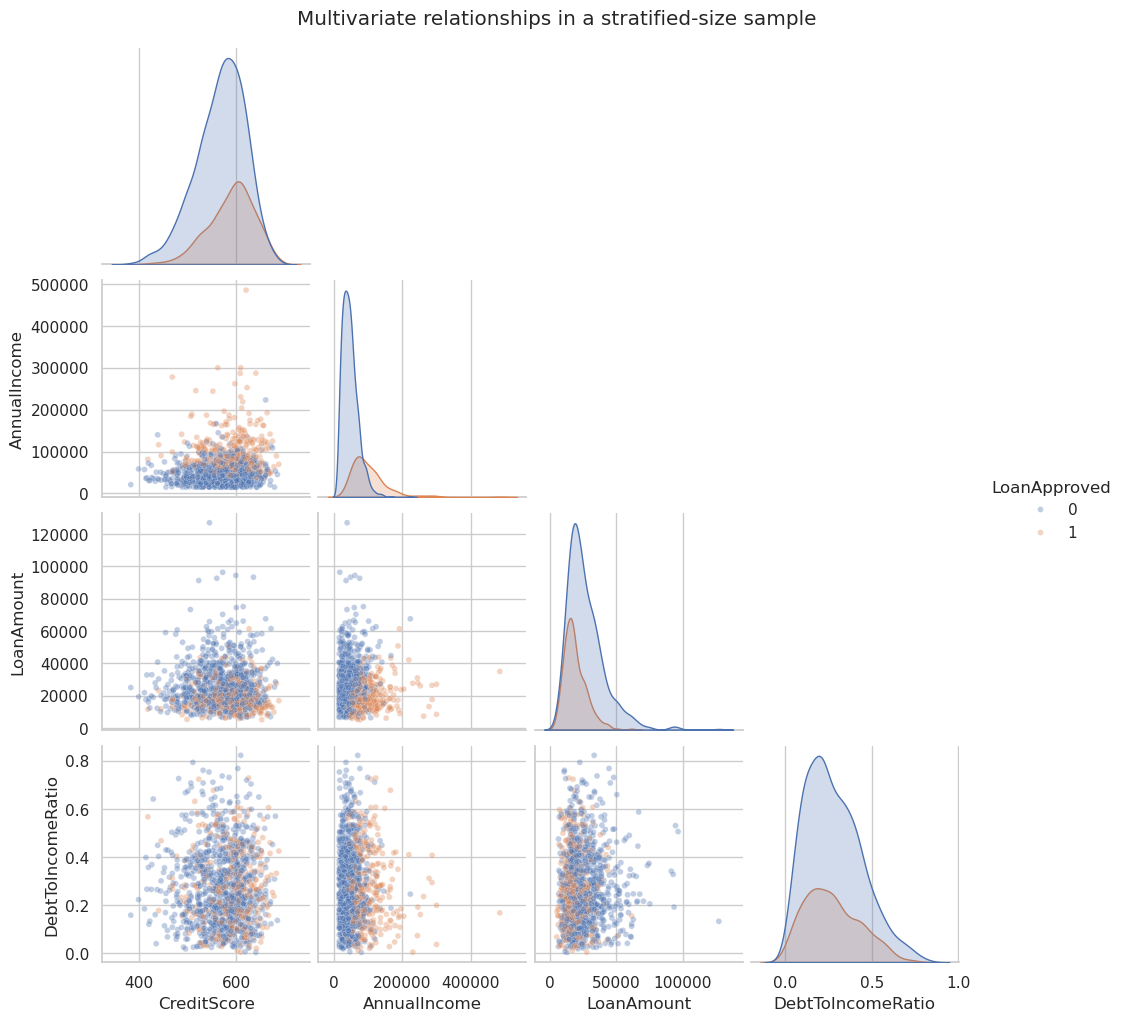

In [8]:
# Visualization 11: multivariate sample (sampling keeps the plot legible)
pair_cols = ["CreditScore", "AnnualIncome", "LoanAmount", "DebtToIncomeRatio", "LoanApproved"]
pair_sample = eda[pair_cols].dropna().sample(n=1200, random_state=RANDOM_STATE)
sns.pairplot(pair_sample, vars=pair_cols[:-1], hue="LoanApproved", corner=True, plot_kws={"alpha": 0.35, "s": 18})
plt.suptitle("Multivariate relationships in a stratified-size sample", y=1.02)
plt.show()

### Statistical association checks

Visual differences can occur by chance in large tables, so the following screening tests quantify univariate association. Point-biserial correlations test numeric features against the binary target; chi-square tests screen nominal distributions. These tests do **not** establish causality, and p-values will be small for even modest effects at $n=20{,}000$, so effect magnitude and business plausibility matter more than significance alone.

In [9]:
numeric_for_tests = [c for c in eda.select_dtypes(include=np.number).columns if c not in ["LoanApproved", "RiskScore"]]
numeric_tests = []
for col in numeric_for_tests:
    subset = eda[[col, "LoanApproved"]].dropna()
    r, p = pointbiserialr(subset["LoanApproved"], subset[col])
    numeric_tests.append((col, r, p))
numeric_tests = pd.DataFrame(numeric_tests, columns=["feature", "point_biserial_r", "p_value"])
numeric_tests["abs_r"] = numeric_tests["point_biserial_r"].abs()

categorical_tests = []
for col in ["EmploymentStatus", "EducationLevel", "MaritalStatus", "HomeOwnershipStatus", "BankruptcyHistory", "LoanPurpose"]:
    table = pd.crosstab(eda[col].fillna("Missing"), eda["LoanApproved"])
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt((chi2 / n) / max(1, min(table.shape[0] - 1, table.shape[1] - 1)))
    categorical_tests.append((col, chi2, p, cramers_v))
categorical_tests = pd.DataFrame(categorical_tests, columns=["feature", "chi2", "p_value", "cramers_v"])

print("Strongest numeric associations (RiskScore intentionally omitted):")
display(numeric_tests.sort_values("abs_r", ascending=False).head(12))
print("Categorical associations:")
display(categorical_tests.sort_values("cramers_v", ascending=False))

Strongest numeric associations (RiskScore intentionally omitted):


,feature,point_biserial_r,p_value,abs_r
19,MonthlyIncome,0.604101,0.000000e+00,0.604101
1,AnnualIncome,0.597900,0.000000e+00,0.597900
26,TotalDebtToIncomeRatio,-0.410399,0.000000e+00,0.410399
24,InterestRate,-0.301646,0.000000e+00,0.301646
23,BaseInterestRate,-0.247263,2.502373e-276,0.247263
4,LoanAmount,-0.239496,7.325162e-259,0.239496
22,NetWorth,0.187892,2.510810e-158,0.187892
25,MonthlyLoanPayment,-0.184272,2.945711e-152,0.184272
17,TotalAssets,0.184011,7.979694e-152,0.184011
2,CreditScore,0.142000,1.381666e-90,0.142000


Categorical associations:


,feature,chi2,p_value,cramers_v
1,EducationLevel,1068.927568,7.157929e-229,0.231185
4,BankruptcyHistory,99.370892,2.093774e-23,0.070488
0,EmploymentStatus,38.506520,4.349261e-09,0.043879
3,HomeOwnershipStatus,26.328828,8.138932e-06,0.036283
5,LoanPurpose,6.695746,1.528671e-01,0.018297
2,MaritalStatus,1.373997,8.487016e-01,0.008289


## 3. Data Preparation

All learned transformations occur inside a scikit-learn pipeline, preventing validation leakage. The custom `LoanFeatureEngineer` parses currency and creates three affordability features. Numeric fields use median imputation and scaling; the ordered education field receives explicit ordinal encoding; nominal fields use most-frequent imputation and unknown-safe one-hot encoding. `RiskScore` is removed before splitting. No rows are deleted solely for missingness or skew.

In [10]:
class LoanFeatureEngineer(BaseEstimator, TransformerMixin):
    # Parse currency and add transparent affordability features.
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["AnnualIncome"] = pd.to_numeric(
            X["AnnualIncome"].astype(str).str.replace(r"[$,]", "", regex=True),
            errors="coerce",
        )
        income = X["AnnualIncome"].replace(0, np.nan)
        liabilities = X["TotalLiabilities"].replace(0, np.nan)
        X["LoanToIncomeRatio"] = X["LoanAmount"] / income
        X["LiquidAccountBalance"] = X["SavingsAccountBalance"] + X["CheckingAccountBalance"]
        X["AssetCoverageRatio"] = X["TotalAssets"] / liabilities
        return X

    def get_feature_names_out(self, input_features=None):
        features = list(input_features) if input_features is not None else []
        return np.asarray(features + ["LoanToIncomeRatio", "LiquidAccountBalance", "AssetCoverageRatio"], dtype=object)


target = "LoanApproved"
leakage_features = ["RiskScore"]
X = data.drop(columns=[target] + leakage_features)
y = data[target].astype(int)

ordinal_features = ["EducationLevel"]
nominal_features = [
    "EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus",
    "BankruptcyHistory", "LoanPurpose"
]
numeric_features = [
    c for c in X.columns if c not in ordinal_features + nominal_features
] + ["LoanToIncomeRatio", "LiquidAccountBalance", "AssetCoverageRatio"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
ordinal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=[["High School", "Associate", "Bachelor", "Master", "Doctorate"]],
        handle_unknown="use_encoded_value", unknown_value=-1,
    )),
    ("scaler", StandardScaler()),
])
nominal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent", add_indicator=True)),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("ordinal", ordinal_pipeline, ordinal_features),
    ("nominal", nominal_pipeline, nominal_features),
], verbose_feature_names_out=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print(f"Training approval rate: {y_train.mean():.3f} | Test approval rate: {y_test.mean():.3f}")

Training rows: 16,000 | Test rows: 4,000
Training approval rate: 0.239 | Test approval rate: 0.239


## 4. Modeling

Five non-trivial model families are compared under the same preprocessing and stratified five-fold splits. Logistic regression is the leading deployment candidate because coefficients can support reason codes; tree and ensemble models test whether nonlinear interactions provide enough lift to justify reduced interpretability. The dummy model quantifies the no-skill baseline.

,model,roc_auc,pr_auc,recall,precision,f1,mean_fold_cost
0,Logistic regression,0.995,0.984,0.967,0.868,0.915,"$5,843,200"
4,Gradient boosting,0.989,0.968,0.871,0.918,0.894,"$3,780,400"
3,Extra trees,0.980,0.944,0.891,0.832,0.860,"$7,575,600"
2,Random forest,0.977,0.934,0.853,0.837,0.844,"$7,272,400"
1,Decision tree,0.948,0.856,0.900,0.696,0.785,"$15,629,600"


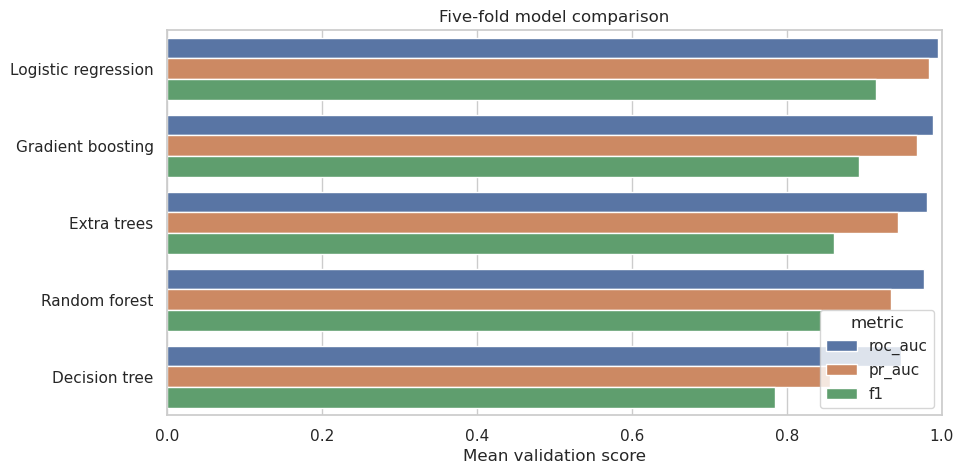

In [11]:
FALSE_APPROVAL_COST = 50_000
FALSE_DENIAL_COST = 8_000

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return FALSE_APPROVAL_COST * fp + FALSE_DENIAL_COST * fn

neg_cost_scorer = make_scorer(business_cost, greater_is_better=False)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "neg_cost": neg_cost_scorer,
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Logistic regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision tree": DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
    "Random forest": RandomForestClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "Extra trees": ExtraTreesClassifier(n_estimators=250, min_samples_leaf=3, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE),
}

comparison_rows = []
for name, estimator in models.items():
    pipe = Pipeline([
        ("features", LoanFeatureEngineer()),
        ("preprocess", preprocessor),
        ("model", estimator),
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    comparison_rows.append({
        "model": name,
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean(),
        "recall": scores["test_recall"].mean(),
        "precision": scores["test_precision"].mean(),
        "f1": scores["test_f1"].mean(),
        "mean_fold_cost": -scores["test_neg_cost"].mean(),
    })

comparison = pd.DataFrame(comparison_rows).sort_values("roc_auc", ascending=False)
display(comparison.style.format({
    "roc_auc": "{:.3f}", "pr_auc": "{:.3f}", "recall": "{:.3f}",
    "precision": "{:.3f}", "f1": "{:.3f}", "mean_fold_cost": "${:,.0f}",
}))

# Visualization 12: model comparison
plot_compare = comparison.melt(id_vars="model", value_vars=["roc_auc", "pr_auc", "f1"], var_name="metric", value_name="score")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_compare, x="score", y="model", hue="metric", ax=ax)
ax.set(title="Five-fold model comparison", xlim=(0, 1), xlabel="Mean validation score", ylabel="")
plt.show()

### Hyperparameter optimization

The interpretable logistic pipeline is tuned with 20 sampled configurations across regularization type/strength, class weighting, and numeric imputation strategy. All candidates are scored on ROC-AUC, PR-AUC, F1, and portfolio cost. ROC-AUC is the refit criterion because threshold-specific financial cost is optimized separately on out-of-fold probabilities; this separation avoids baking an arbitrary 0.50 threshold into model selection.

In [12]:
logistic_pipeline = Pipeline([
    ("features", LoanFeatureEngineer()),
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=3000, solver="liblinear", random_state=RANDOM_STATE)),
])

param_distributions = {
    "preprocess__numeric__imputer__strategy": ["median", "mean"],
    "model__penalty": ["l1", "l2"],
    "model__C": np.logspace(-2, 2, 20),
    "model__class_weight": [None, "balanced", {0: 6.25, 1: 1.0}],
}

random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
)
random_search.fit(X_train, y_train)
model = random_search.best_estimator_

print("Best parameters:")
display(random_search.best_params_)
print(f"Best mean CV ROC-AUC: {random_search.best_score_:.4f}")

random_search_results = pd.DataFrame(random_search.cv_results_).sort_values("rank_test_roc_auc").head(10)
display(random_search_results[[
    "rank_test_roc_auc", "mean_test_roc_auc", "mean_test_pr_auc", "mean_test_f1",
    "mean_test_neg_cost", "param_model__C", "param_model__penalty",
    "param_model__class_weight", "param_preprocess__numeric__imputer__strategy"
]].assign(mean_test_cost=lambda d: -d.pop("mean_test_neg_cost")))

Best parameters:


{'preprocess__numeric__imputer__strategy': 'mean',
 'model__penalty': 'l1',
 'model__class_weight': None,
 'model__C': np.float64(0.7847599703514611)}

Best mean CV ROC-AUC: 0.9947


,rank_test_roc_auc,mean_test_roc_auc,mean_test_pr_auc,mean_test_f1,param_model__C,param_model__penalty,param_model__class_weight,param_preprocess__numeric__imputer__strategy,mean_test_cost
3,1,0.994725,0.984169,0.925060,0.784760,l1,None,mean,3198400.0
13,2,0.994700,0.984099,0.925046,8.858668,l1,None,median,3198400.0
19,3,0.994694,0.984034,0.916683,1.274275,l1,balanced,mean,5653200.0
14,4,0.994693,0.984037,0.916250,0.784760,l1,balanced,mean,5701600.0
11,5,0.994676,0.984054,0.924923,37.926902,l2,None,median,3208400.0
15,6,0.994670,0.984042,0.925046,100.000000,l2,None,median,3198400.0
5,7,0.994644,0.983905,0.917207,8.858668,l1,balanced,median,5586400.0
4,8,0.994644,0.983998,0.882043,0.483293,l1,"{0: 6.25, 1: 1.0}",median,1710400.0
2,9,0.994643,0.983995,0.879894,0.297635,l1,"{0: 6.25, 1: 1.0}",mean,1679200.0
6,10,0.994643,0.983900,0.917414,100.000000,l1,balanced,mean,5558000.0


### Cost-sensitive threshold selection

Threshold selection uses only out-of-fold training predictions from the selected pipeline. The untouched test set remains a one-time estimate of generalization. The theoretical 0.862 threshold is shown alongside the empirical minimum-cost point.

Selected OOF threshold: 0.845


,value
threshold,8.450000e-01
cost,8.438000e+06
recall,8.009937e-01
precision,9.848875e-01
f1,8.834727e-01


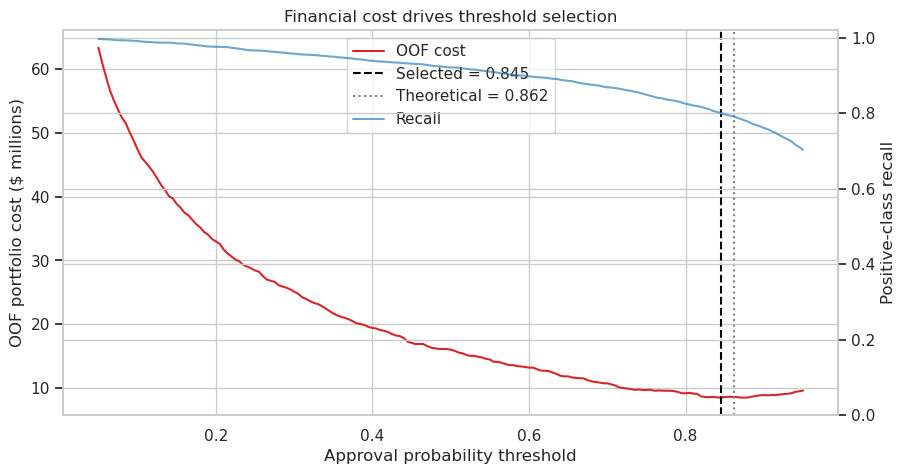

In [13]:
oof_probability = cross_val_predict(
    model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
threshold_rows = []
for threshold in thresholds:
    pred = (oof_probability >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "cost": business_cost(y_train, pred),
        "recall": recall_score(y_train, pred, zero_division=0),
        "precision": precision_score(y_train, pred, zero_division=0),
        "f1": f1_score(y_train, pred, zero_division=0),
    })
threshold_results = pd.DataFrame(threshold_rows)
selected_row = threshold_results.loc[threshold_results["cost"].idxmin()]
selected_threshold = float(selected_row["threshold"])

print(f"Selected OOF threshold: {selected_threshold:.3f}")
display(selected_row.to_frame("value"))

# Visualization 13: cost and recall across thresholds
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(threshold_results["threshold"], threshold_results["cost"] / 1e6, color="tab:red", label="OOF cost")
ax1.axvline(selected_threshold, color="black", linestyle="--", label=f"Selected = {selected_threshold:.3f}")
ax1.axvline(50_000 / 58_000, color="gray", linestyle=":", label="Theoretical = 0.862")
ax1.set(xlabel="Approval probability threshold", ylabel="OOF portfolio cost ($ millions)", title="Financial cost drives threshold selection")
ax2 = ax1.twinx()
ax2.plot(threshold_results["threshold"], threshold_results["recall"], color="tab:blue", alpha=0.65, label="Recall")
ax2.set(ylabel="Positive-class recall", ylim=(0, 1.02))
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper center")
plt.show()

## 5. Evaluation and Conclusion

The final pipeline is now evaluated once on the held-out 20% test set. Results are shown at both the conventional 0.50 threshold and the cost-selected threshold so the operational trade-off is explicit.

In [14]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred_default = (y_pred_proba >= 0.50).astype(int)
y_pred = (y_pred_proba >= selected_threshold).astype(int)

def evaluation_row(name, y_true, pred, probability):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "strategy": name,
        "accuracy": accuracy_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "false_approvals": fp,
        "false_denials": fn,
        "business_cost": business_cost(y_true, pred),
    }

always_deny = np.zeros_like(y_test)
always_approve = np.ones_like(y_test)
evaluation = pd.DataFrame([
    evaluation_row("Always deny", y_test, always_deny, np.full(len(y_test), y_train.mean())),
    evaluation_row("Always approve", y_test, always_approve, np.full(len(y_test), y_train.mean())),
    evaluation_row("Model @ 0.50", y_test, y_pred_default, y_pred_proba),
    evaluation_row(f"Model @ {selected_threshold:.3f}", y_test, y_pred, y_pred_proba),
])
display(evaluation.style.format({
    "accuracy": "{:.3f}", "roc_auc": "{:.3f}", "pr_auc": "{:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
    "business_cost": "${:,.0f}",
}))

baseline_cost = business_cost(y_test, always_deny)
final_cost = business_cost(y_test, y_pred)
cost_reduction = 1 - final_cost / baseline_cost
print(f"Cost reduction versus always deny: {cost_reduction:.1%}")
print("\nClassification report at cost-selected threshold:")
print(classification_report(y_test, y_pred, target_names=["Denied / bad", "Approved / good"], digits=3))

,strategy,accuracy,roc_auc,pr_auc,precision,recall,f1,false_approvals,false_denials,business_cost
0,Always deny,0.761,0.500,0.239,0.000,0.000,0.000,0,956,"$7,648,000"
1,Always approve,0.239,0.500,0.239,0.239,1.000,0.386,3044,0,"$152,200,000"
2,Model @ 0.50,0.966,0.995,0.984,0.932,0.926,0.929,65,71,"$3,818,000"
3,Model @ 0.845,0.949,0.995,0.984,0.977,0.803,0.882,18,188,"$2,404,000"


Cost reduction versus always deny: 68.6%

Classification report at cost-selected threshold:
                 precision    recall  f1-score   support

   Denied / bad      0.942     0.994     0.967      3044
Approved / good      0.977     0.803     0.882       956

       accuracy                          0.949      4000
      macro avg      0.959     0.899     0.924      4000
   weighted avg      0.950     0.949     0.947      4000



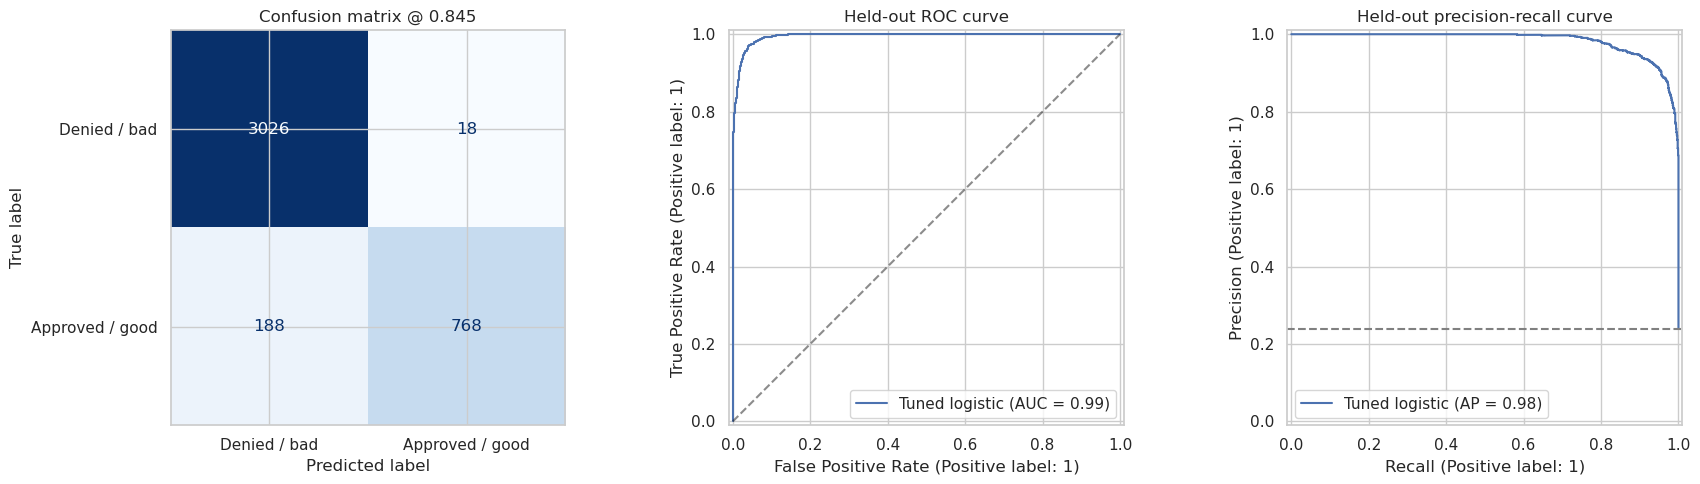

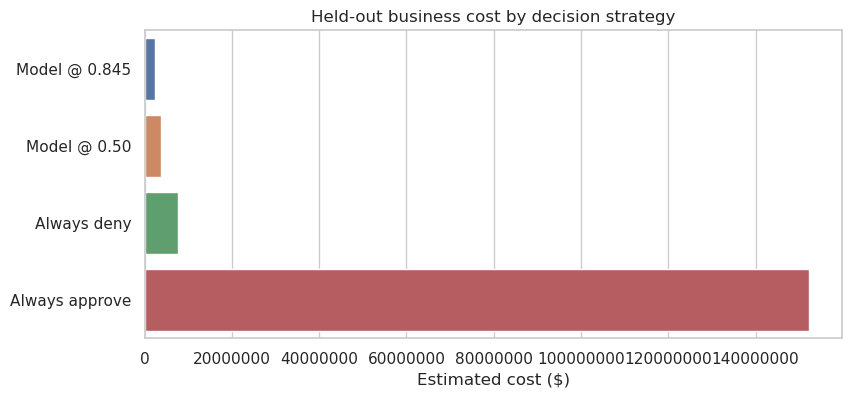

In [15]:
# Visualizations 14-16: confusion matrix, ROC curve, and precision-recall curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Denied / bad", "Approved / good"],
    cmap="Blues", colorbar=False, ax=axes[0]
)
axes[0].set_title(f"Confusion matrix @ {selected_threshold:.3f}")
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name="Tuned logistic")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("Held-out ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[2], name="Tuned logistic")
axes[2].axhline(y_test.mean(), color="gray", linestyle="--", label="Prevalence")
axes[2].set_title("Held-out precision-recall curve")
plt.tight_layout()
plt.show()

# Visualization 17: portfolio cost comparison
fig, ax = plt.subplots(figsize=(9, 4))
cost_plot = evaluation.sort_values("business_cost")
sns.barplot(data=cost_plot, x="business_cost", y="strategy", hue="strategy", legend=False, ax=ax)
ax.set(title="Held-out business cost by decision strategy", xlabel="Estimated cost ($)", ylabel="")
ax.ticklabel_format(style="plain", axis="x")
plt.show()

### Interpretation and feature importance

For a scaled logistic model, coefficient sign indicates whether a feature raises or lowers approval log-odds, while absolute magnitude ranks influence. One-hot levels are interpreted relative to the omitted combination of other encoded levels—not as causal effects. Correlated financial variables can distribute weight across one another, so permutation importance and stability checks should precede production reason codes.

,feature,coefficient,absolute_coefficient
26,TotalDebtToIncomeRatio,-9.692314,9.692314
45,BankruptcyHistory_Yes,-6.889200,6.889200
24,InterestRate,-5.626694,5.626694
19,MonthlyIncome,4.984766,4.984766
35,EmploymentStatus_Unemployed,-3.530624,3.530624
22,NetWorth,3.046620,3.046620
2,CreditScore,-2.627561,2.627561
4,LoanAmount,-2.082332,2.082332
14,LengthOfCreditHistory,1.809730,1.809730
32,EducationLevel,1.564335,1.564335


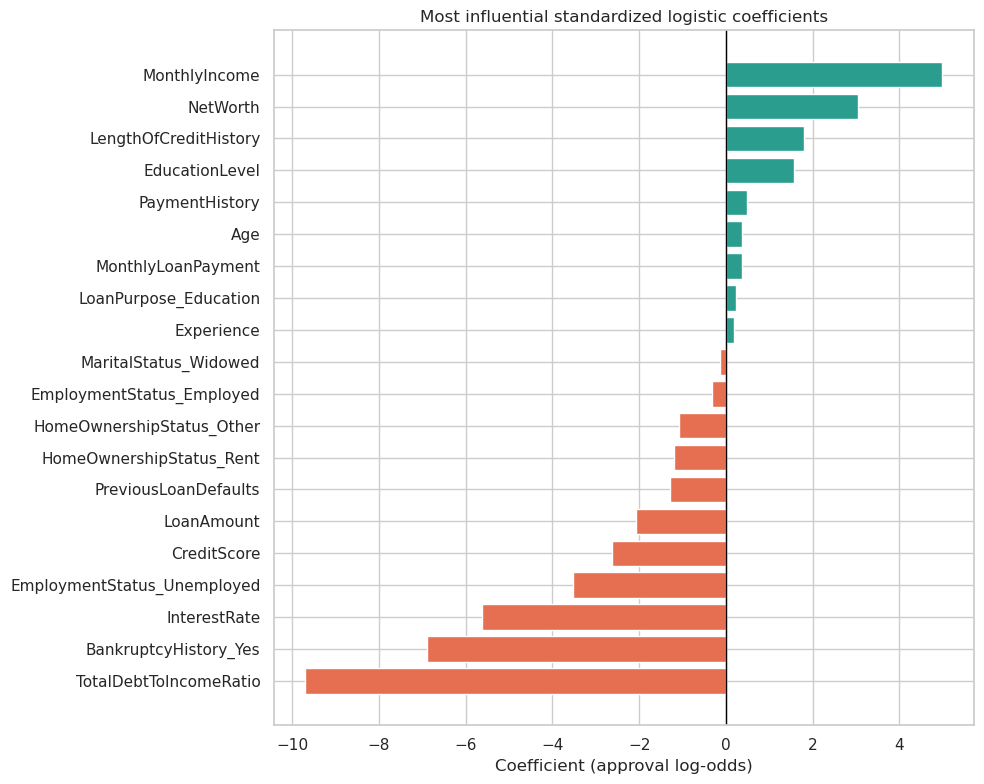

In [16]:
feature_names = model.named_steps["preprocess"].get_feature_names_out()
coefficients = model.named_steps["model"].coef_[0]
importance = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
importance["absolute_coefficient"] = importance["coefficient"].abs()
top_importance = importance.nlargest(20, "absolute_coefficient").sort_values("coefficient")
display(importance.nlargest(20, "absolute_coefficient"))

# Visualization 18: signed coefficient importance
fig, ax = plt.subplots(figsize=(10, 8))
colors = np.where(top_importance["coefficient"] >= 0, "#2a9d8f", "#e76f51")
ax.barh(top_importance["feature"], top_importance["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Most influential standardized logistic coefficients", xlabel="Coefficient (approval log-odds)", ylabel="")
plt.tight_layout()
plt.show()

### Segment performance and bias limitations

Aggregate performance can conceal unequal errors. The audit below reports error rates and cost per applicant by age band, employment status, and education. Age, marital status, and education can act as protected or socioeconomic proxies. This dataset does not include race, sex, disability, or other legally relevant groups, and the target reproduces historical approvals rather than observed repayment outcomes; therefore this is a diagnostic, **not** proof of fairness.

,segment_type,segment,n,actual_approval_rate,predicted_approval_rate,false_positive_rate,false_negative_rate,cost_per_application
0,AgeBand,18-29,773,13.32%,12.55%,0.90%,11.65%,$512
1,AgeBand,30-44,1877,24.19%,18.27%,0.28%,25.33%,$597
2,AgeBand,45-59,1152,28.47%,23.61%,0.24%,17.68%,$490
3,AgeBand,60-80,198,35.86%,37.37%,4.72%,4.23%,"$1,636"
4,EmploymentStatus,Employed,3402,24.22%,19.81%,0.47%,19.66%,$557
5,EmploymentStatus,Self-Employed,311,26.37%,23.47%,1.75%,15.85%,$977
6,EmploymentStatus,Unemployed,287,17.42%,13.59%,0.84%,26.00%,$711
7,EducationLevel,Associate,782,20.72%,15.98%,0.81%,25.93%,$749
8,EducationLevel,Bachelor,1163,27.94%,23.47%,0.60%,17.54%,$607
9,EducationLevel,Doctorate,156,44.23%,39.74%,0.00%,10.14%,$359


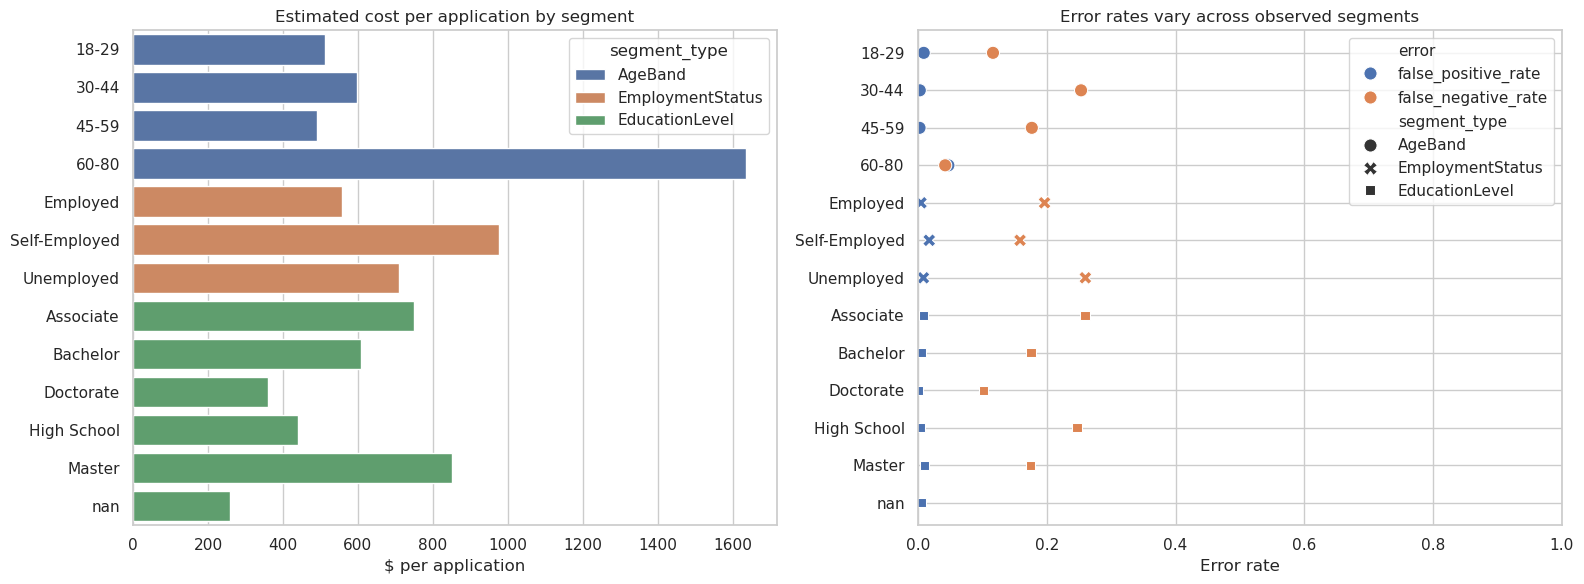

In [17]:
audit = X_test[["Age", "EmploymentStatus", "EducationLevel"]].copy()
audit["AgeBand"] = pd.cut(audit["Age"], bins=[17, 29, 44, 59, 80], labels=["18-29", "30-44", "45-59", "60-80"])
audit["actual"] = y_test.values
audit["predicted"] = y_pred

def segment_metrics(frame, group_col):
    rows = []
    for group, part in frame.groupby(group_col, dropna=False, observed=False):
        if len(part) < 100:
            continue
        tn, fp, fn, tp = confusion_matrix(part["actual"], part["predicted"], labels=[0, 1]).ravel()
        rows.append({
            "segment_type": group_col,
            "segment": str(group),
            "n": len(part),
            "actual_approval_rate": part["actual"].mean(),
            "predicted_approval_rate": part["predicted"].mean(),
            "false_positive_rate": fp / (fp + tn) if fp + tn else np.nan,
            "false_negative_rate": fn / (fn + tp) if fn + tp else np.nan,
            "cost_per_application": (FALSE_APPROVAL_COST * fp + FALSE_DENIAL_COST * fn) / len(part),
        })
    return pd.DataFrame(rows)

segment_results = pd.concat([
    segment_metrics(audit, "AgeBand"),
    segment_metrics(audit, "EmploymentStatus"),
    segment_metrics(audit, "EducationLevel"),
], ignore_index=True)
display(segment_results.style.format({
    "actual_approval_rate": "{:.2%}", "predicted_approval_rate": "{:.2%}",
    "false_positive_rate": "{:.2%}", "false_negative_rate": "{:.2%}",
    "cost_per_application": "${:,.0f}",
}))

# Visualization 19: segment error comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=segment_results, x="cost_per_application", y="segment", hue="segment_type", ax=axes[0])
axes[0].set(title="Estimated cost per application by segment", xlabel="$ per application", ylabel="")
error_long = segment_results.melt(
    id_vars=["segment_type", "segment"],
    value_vars=["false_positive_rate", "false_negative_rate"],
    var_name="error", value_name="rate",
)
sns.scatterplot(data=error_long, x="rate", y="segment", hue="error", style="segment_type", s=90, ax=axes[1])
axes[1].set(title="Error rates vary across observed segments", xlabel="Error rate", ylabel="", xlim=(0, 1))
plt.tight_layout()
plt.show()

## Final Conclusion and Recommendations

### Executive summary

The final cost-sensitive logistic pipeline led the five-model comparison and met every predefined goal. On 4,000 untouched test applications it produced **0.995 ROC-AUC**, **0.984 PR-AUC**, **97.7% precision**, and **80.3% recall** at the training-selected **0.845** threshold. It made 18 false approvals and 188 false denials, for an estimated **$2.404 million** cost versus **$7.648 million** from always denying—a **68.6% reduction**. The conventional 0.50 threshold cost $3.818 million, demonstrating why threshold policy matters. These figures estimate agreement with historical approvals under fixed average costs, not future default prevention or causal creditworthiness.

### Recommended implementation

1. **Deploy as decision support first.** Auto-route only very high-confidence cases; send borderline cases and all adverse decisions to trained officers with reason codes and an appeal workflow.
2. **Confirm feature availability.** Remove any pricing/payment field created after approval. Retest a reduced pre-decision feature set before launch.
3. **Replace the proxy outcome.** Join applications to observed repayment/default outcomes. Historical approval labels encode the old policy and do not prove creditworthiness for denied applicants (selective-label bias).
4. **Calibrate and validate prospectively.** Check probability calibration, expected cost under realistic default/profit estimates, temporal drift, and threshold stability on a later application cohort.
5. **Govern fairness.** Run legally reviewed adverse-impact and equal-opportunity analyses with appropriate protected-class data; challenge or remove age, marital status, education, and other proxies where required.
6. **Monitor monthly.** Track input missingness/drift, approval rate, ROC/PR metrics after outcomes mature, false-approval and false-denial costs, segment gaps, overrides, and appeals. Trigger review when performance or disparity exceeds agreed tolerances.

### Limitations and next improvements

The data is observational and appears partly synthetic; costs are fixed averages rather than applicant-specific exposure; denied applicants lack counterfactual repayment outcomes; and random splitting may overstate future performance when policies or the economy change. Next work should use an out-of-time test, calibrated probabilities, reject inference or experimental data where lawful, monotonic/constraint-aware models, permutation or SHAP stability checks, and scenario analysis over changing loss assumptions. A human-governed pilot is warranted; autonomous approval is not.